In [33]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage import filters
from skimage import exposure, feature
from scipy.stats import mode
import cv2

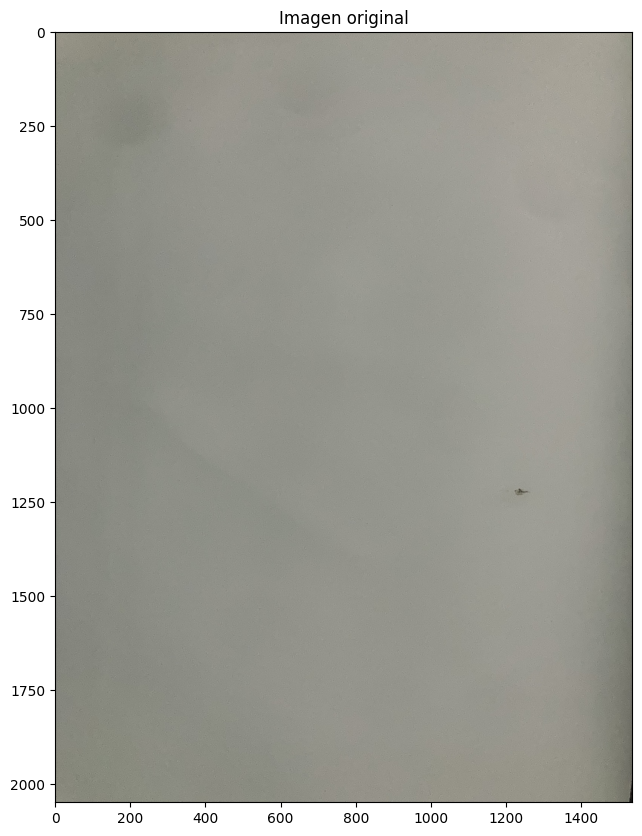

In [34]:
# Cargar la imagen
ref1 = ['IMG_2377.JPEG', 'IMG_2380.JPEG', 'IMG_2381.JPEG', 'IMG_2382.JPEG', 'IMG_2383.JPEG']
ref2 = ['IMG_2385.JPEG', 'IMG_2386.JPEG', 'IMG_2387.JPEG', 'IMG_2388.JPEG', 'IMG_2389.JPEG', 'IMG_2390.JPEG', 'IMG_2391.JPEG', 'IMG_2392.JPEG']
ref3 = ['IMG_2393.JPEG', 'IMG_2394.JPEG', 'IMG_2395.JPEG', 'IMG_2396.JPEG', 'IMG_2397.JPEG', 'IMG_2398.JPEG', 'IMG_2399.JPEG', 'IMG_2400.JPEG', 'IMG_2401.JPEG']
ref4 = ['IMG_2402.JPEG', 'IMG_2403.JPEG', 'IMG_2404.JPEG', 'IMG_2405.JPEG', 'IMG_2406.JPEG', 'IMG_2407.JPEG', 'IMG_2408.JPEG', 'IMG_2409.JPEG', 'IMG_2410.JPEG', 'IMG_2411.JPEG', 'IMG_2412.JPEG', 'IMG_2413.JPEG', 'IMG_2414.JPEG', 'IMG_2415.JPEG']
ref5 = ['IMG_2416.JPEG', 'IMG_2417.JPEG', 'IMG_2418.JPEG', 'IMG_2419.JPEG', 'IMG_2420.JPEG', 'IMG_2421.JPEG', 'IMG_2422.JPEG', 'IMG_2423.JPEG', 'IMG_2425.JPEG']
ref6 = ['IMG_2426.JPEG', 'IMG_2427.JPEG', 'IMG_2428.JPEG', 'IMG_2429.JPEG', 'IMG_2430.JPEG', 'IMG_2431.JPEG', 'IMG_2432.JPEG', 'IMG_2433.JPEG', 'IMG_2434.JPEG']
image_path = '../images/' + ref5[0]
image = cv2.imread(image_path)
# Mostrar la imagen
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.show()

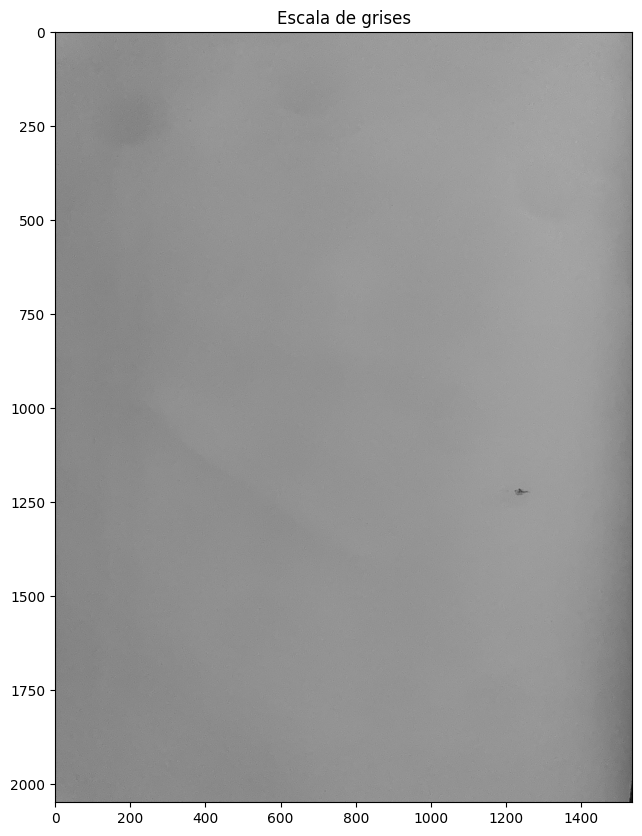

In [35]:
# Convertir a escala de grises
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Mostrar la imagen
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.title('Escala de grises')
plt.show()

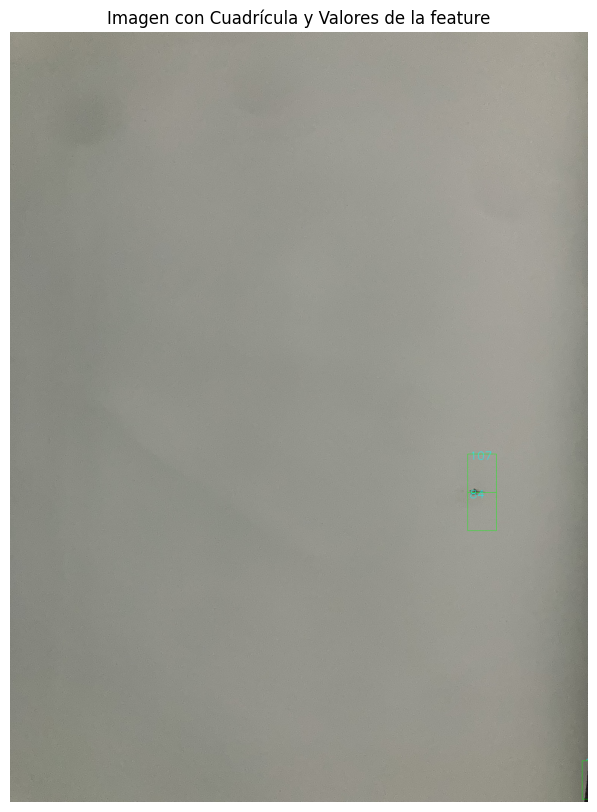

In [36]:
def calculate_feature(image):
    """Calcula la feature de una imagen."""
    flattened = image.flatten()
    min_value = np.min(flattened)
    mode_result = mode(flattened)  # Obtener la moda y el conteo
    mode_value = mode_result.mode
    value = mode_value - min_value
    return value


# Dividir la imagen en zonas
grid_size = 20  # Ajusta el tamaño de la cuadrícula
h, w = gray.shape
step_h = h // grid_size
step_w = w // grid_size

features = []

# Crear una copia de la imagen para dibujar la cuadrícula
output_image = image.copy()

# Recorrer la imagen por zonas
for i in range(0, h, step_h):
    for j in range(0, w, step_w):
        # Definir la zona
        zone = gray[i:i+step_h, j:j+step_w]
        
        # Calcular la feature de la zona
        value = calculate_feature(zone)
        features.append(value)
        
        if value > 80:
            # Dibujar la cuadrícula
            cv2.rectangle(output_image, (j, i), (j + step_w, i + step_h), (0, 255, 0), 1)
        
            # Mostrar el valor de entropía en la cuadrícula
            cv2.putText(output_image, f"{value:.0f}", (j + 5, i + 15), 
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 1, cv2.LINE_AA)

# Mostrar la imagen con la cuadrícula y valores de entropía
plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))  # Convertir BGR a RGB
plt.title('Imagen con Cuadrícula y Valores de la feature')
plt.axis('off')
plt.show()